Dataset              Lignes Colonnes
UAVIDS-2025          122171       23
Bruteforce             5103       45
DDoS                  14292       45
DoS                   14121       45
Evil                     48       45
Fakelanding             200       45
MITM                   1164       45
Reconnassiance        50135       45
Reply                   792       45
Scanning              50135       45
Normal               149434       45

Colonnes (UAVIDS-2025) :
['FlowID', 'FlowDuration/s', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort', 'Protocol', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount', 'label']

Aperçu (UAVIDS-2025) :
   FlowID  FlowDuration/s        SrcAddr  SrcPort       DstAddr  DstPort  \
0       1         175.007  192.168.0.150        9  192.168.0.16        9   
1       2         175.00

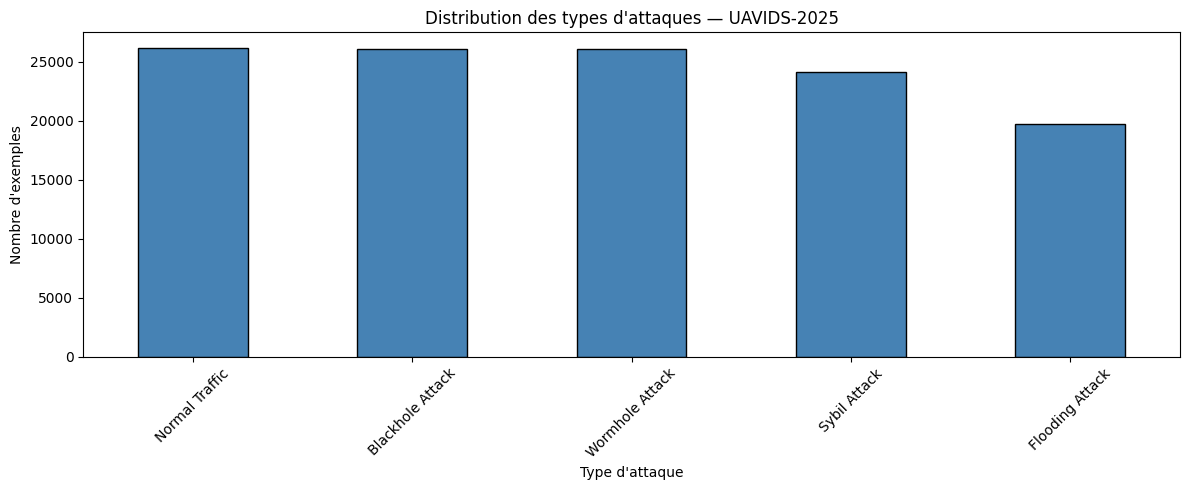

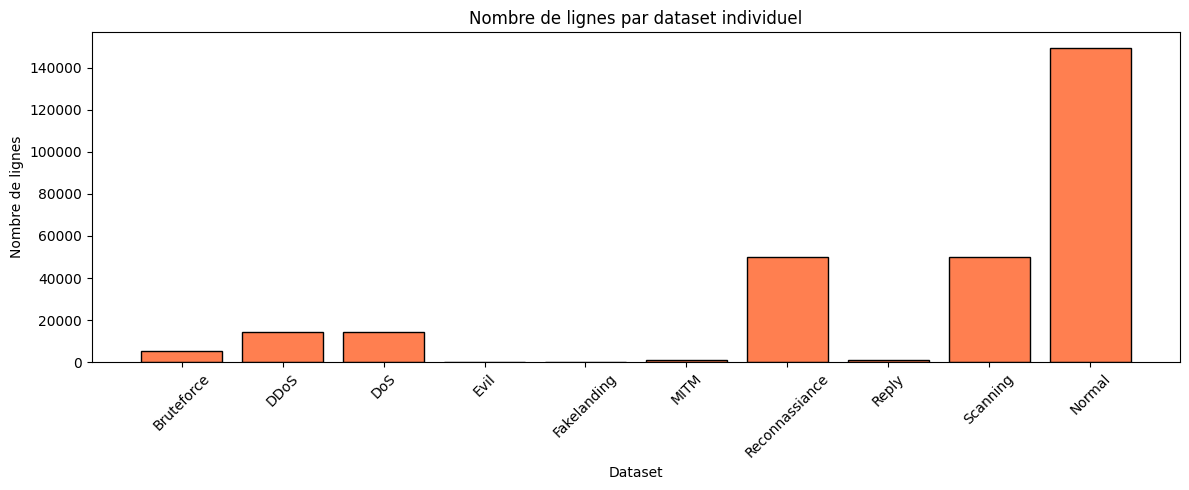

Tous les fichiers CSV exportés dans Rapport/tables/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Rechargement des données
df_uavids         = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\UAVIDS-2025\UAVIDS-2025.csv")
df_bruteforce     = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\BruteforceC.csv")
df_ddos           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\DDoSC.csv")
df_dos            = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\DoSC.csv")
df_evil           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\EvilC.csv")
df_fakelanding    = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\FakelandingC.csv")
df_mitm           = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\MITMC.csv")
df_reconnassiance = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ReconnassianceC.csv")
df_reply          = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ReplyC.csv")
df_scanning       = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\Each_Attacks_CSV\ScanningC.csv")
df_normal         = pd.read_csv(r"C:\Drone_Attack_Similarity_Project\DATASET\Brutes\NomralAttacks\Normal.csv")

# Dictionnaire de tous les datasets
datasets = {
    "UAVIDS-2025"   : df_uavids,
    "Bruteforce"    : df_bruteforce,
    "DDoS"          : df_ddos,
    "DoS"           : df_dos,
    "Evil"          : df_evil,
    "Fakelanding"   : df_fakelanding,
    "MITM"          : df_mitm,
    "Reconnassiance": df_reconnassiance,
    "Reply"         : df_reply,
    "Scanning"      : df_scanning,
    "Normal"        : df_normal,
}

# Exploration des données

# 1. Taille de chaque dataset
print("=" * 45)
print(f"{'Dataset':<18} {'Lignes':>8} {'Colonnes':>8}")
print("=" * 45)
for name, df in datasets.items():
    print(f"{name:<18} {df.shape[0]:>8} {df.shape[1]:>8}")

# 2. Colonnes disponibles
print("\nColonnes (UAVIDS-2025) :")
print(df_uavids.columns.tolist())

# 3. Aperçu des données
print("\nAperçu (UAVIDS-2025) :")
print(df_uavids.head())

# 4. Types de données
print("\nTypes de données (UAVIDS-2025) :")
print(df_uavids.dtypes)

# 5. Statistiques descriptives
print("\nStatistiques descriptives (UAVIDS-2025) :")
print(df_uavids.describe())

# 6. Valeurs manquantes
print("\nValeurs manquantes par dataset :")
print("=" * 45)
for name, df in datasets.items():
    n = df.isnull().sum().sum()
    status = "Aucune" if n == 0 else f"{n} valeurs manquantes"
    print(f"{name:<18} → {status}")

# 7. Doublons
print("\nDoublons par dataset :")
print("=" * 45)
for name, df in datasets.items():
    n = df.duplicated().sum()
    status = " Aucun" if n == 0 else f" {n} doublons"
    print(f"{name:<18} → {status}")

# 8. Distribution des labels
print("\nDistribution des labels (UAVIDS-2025) :")
print(df_uavids["label"].value_counts())

plt.figure(figsize=(12, 5))
df_uavids["label"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution des types d'attaques — UAVIDS-2025")
plt.xlabel("Type d'attaque")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 9. Taille de chaque dataset individuel (graphique)
sizes = {name: df.shape[0] for name, df in datasets.items() if name != "UAVIDS-2025"}

plt.figure(figsize=(12, 5))
plt.bar(sizes.keys(), sizes.values(), color="coral", edgecolor="black")
plt.title("Nombre de lignes par dataset individuel")
plt.xlabel("Dataset")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

######### Exportation des résultats dans des fichiers CSV ########

tables_path = r"C:\Drone_Attack_Similarity_Project\Rapport\tables"
os.makedirs(tables_path, exist_ok=True)

# 1. Shape de chaque dataset
shape_data = pd.DataFrame([
    {"Dataset": name, "Lignes": df.shape[0], "Colonnes": df.shape[1]}
    for name, df in datasets.items()
])
shape_data.to_csv(f"{tables_path}\\shape_datasets.csv", index=False)

# 2. Distribution des labels
df_uavids["label"].value_counts().reset_index().rename(
    columns={"index": "Label", "label": "Nombre"}
).to_csv(f"{tables_path}\\label_distribution.csv", index=False)

# 3. Valeurs manquantes
missing_data = pd.DataFrame([
    {"Dataset": name, "Valeurs_manquantes": df.isnull().sum().sum()}
    for name, df in datasets.items()
])
missing_data.to_csv(f"{tables_path}\\missing_values.csv", index=False)

# 4. Doublons
duplicates_data = pd.DataFrame([
    {"Dataset": name, "Doublons": df.duplicated().sum()}
    for name, df in datasets.items()
])
duplicates_data.to_csv(f"{tables_path}\\duplicates.csv", index=False)

# 5. Statistiques descriptives
df_uavids.describe().to_csv(f"{tables_path}\\stats_descriptives.csv")
print("Tous les fichiers CSV exportés dans Rapport/tables/")


